In [45]:
from langgraph.graph import StateGraph,START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver

In [46]:
load_dotenv()

True

In [47]:
model = ChatGoogleGenerativeAI(
    model = 'gemini-3.5-flash'
)

In [48]:
from langgraph.graph.message import add_messages

class chat(TypedDict):

    message : Annotated[list[BaseMessage],add_messages]

In [49]:
def node(state: chat):

    message = state['message']

    response = model.invoke(message)

    return {'message' : [response]}

In [50]:
checkpointer = MemorySaver()

graph = StateGraph(chat)

graph.add_node('node',node)

graph.add_edge(START,'node')
graph.add_edge('node', END)

workflow = graph.compile(checkpointer=checkpointer)

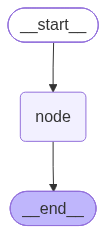

In [51]:
graph.compile()

In [ ]:
initial = {
    "message": [
        HumanMessage(content="capital of India")
    ]
}
workflow.invoke(initial)['message'][-2].content

In [53]:
thread_id = '1'

while True:

    user_message = input('Type Here : ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit','quit', 'bye']:
        break

    config = {
        'configurable' : {'thread_id' : thread_id}
    }
    response =workflow.invoke({'message' : [HumanMessage(content=user_message)]},config=config)

    print('AI:', response['message'][-1].content[0]['text'])

User: hi, i am ash
AI: Hi Ash! It's great to meet you. How can I help you today?
User: what is my name
AI: Your name is Ash!
User: cool 
AI: 😎 

What's on your mind today? Anything I can help you with?
User: what is 10 + 10
AI: 10 + 10 is 20.
User: and 20 to the result
AI: If you add 20 to that result, you get **40**.
User: great , good ai
AI: Thanks, Ash! I'm happy to help. 

What should we tackle next?
User: nothing , bye
AI: Goodbye, Ash! Have a wonderful day, and feel free to reach out whenever you need anything else. Take care!
User: exit


In [55]:
workflow.get_state(config=config)

StateSnapshot(values={'message': [HumanMessage(content='hi, i am ash', additional_kwargs={}, response_metadata={}, id='f17c77be-a157-40be-8c81-169b03d94219'), AIMessage(content=[{'type': 'text', 'text': "Hi Ash! It's great to meet you. How can I help you today?", 'extras': {'signature': 'ErUGCrIGARFNMg+tP5bnl7ZYkmDZ92wFCGcyRJaI3mQx40MSfFjSaye22PPWjTM6MBrgzlHRjaid5r1glruhAcOPQbRIdVdcW1g2NJlYDmNKegU+woXINbIyaM41e5Jix+lQb7+E4MbvxGdfWE7SZd3UspKoP3Ecs7qp/4Z/FfFBA+bGRA5IsOGxGSAUiug/wBKKN+X5IY/c6Z4iVxlT/YEQ/fmCgKUe6CWmm6pTnEbrY41cz7zw/vzqoIlCxQAY5JEbvPC73IIGvfKA0yARqtEvF8NMqZ2XDlcENyOMWui25BePIb9YOVMJkDP3W56rkdti87oqA03EOizP192llgWRKiqpn7ISKJTBw34gCccJxd3yutt+XgNV9BZhLgFvyEgf6MmJRo95e8qg809n4WrBGDzSY4Kk4E+ajP+fMOqFgWI/GKm+VMhiudXCFUua6Vkt9EXGD2tuLViAMkSdfrp6AvWOsbW4Eq2QVzi5mUsvHrgRyx5vJNFq4mkKh7dWr9q4HC/FF+L6eOpLRC7JxnQ7S95DuCdvLYIPKgGDnVQBNaob+EZbXlLjprkSduWqyXdM/tQyzCrJYhflJx/mXfwf5KiqTF5YOIULS7uwQKUgyV7glQO0zN29zim53jNAEGZg+ajL8OCTY5+CdP/QXVJCxCcJPZZoR6JrvS3EaKNze414oqDplYkIp/TZchvGd3c9OK2